# this notebook is for the CNN model

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, 
    confusion_matrix, ConfusionMatrixDisplay
)

# --- 1. Load Dataset ---
local_df = pd.read_csv("../datasets/all_local.csv")
global_df = pd.read_csv("../datasets/all_global.csv")

# Make datasets equal length
min_len = min(len(local_df), len(global_df))
local_df = local_df.iloc[:min_len].reset_index(drop=True)
global_df = global_df.iloc[:min_len].reset_index(drop=True)

# --- 2. Convert labels ---
encoder = LabelEncoder()
y = encoder.fit_transform(global_df["label"])

# --- 3. Drop label column ---
X_local = local_df.drop(columns=["label"])
X_global = global_df.drop(columns=["label"])

print(f"Global features shape: {X_global.shape}")
print(f"Local features shape: {X_local.shape}")

# --- 4. Convert to tensors ---
X_local = torch.tensor(X_local.values, dtype=torch.float32).unsqueeze(1)
X_global = torch.tensor(X_global.values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(y, dtype=torch.long)

print(f"X_global tensor shape: {X_global.shape}")  
print(f"X_local tensor shape: {X_local.shape}")   

# --- 5. Train/test split ---
X_local_train, X_local_test, X_global_train, X_global_test, y_train, y_test = train_test_split(
    X_local, X_global, y, test_size=0.2, random_state=42, stratify=y
)

# --- 6. Create TensorDatasets ---
train_dataset = TensorDataset(X_global_train, X_local_train, y_train)
test_dataset = TensorDataset(X_global_test, X_local_test, y_test)

# --- 7. DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Global features shape: (5300, 2001)
Local features shape: (5300, 201)
X_global tensor shape: torch.Size([5300, 1, 2001])
X_local tensor shape: torch.Size([5300, 1, 201])
Train batches: 67 | Test batches: 17


In [8]:

# ============================================================
# MODEL DEFINITION 
# ============================================================

class ExoplanetCNN(nn.Module):
    def __init__(self, global_length=2001, local_length=201):
        super(ExoplanetCNN, self).__init__()

        # Global branch
        self.global_conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2),

            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2),
        )

        # Local branch
        self.local_conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
        )

        # Compute FC input size dynamically
        with torch.no_grad():
            # Create dummy inputs with correct shapes
            g_dummy = torch.zeros(1, 1, global_length)
            l_dummy = torch.zeros(1, 1, local_length)

            g_out = self.global_conv(g_dummy)
            l_out = self.local_conv(l_dummy)

            g_feat = g_out.view(1, -1).size(1)
            l_feat = l_out.view(1, -1).size(1)
            in_features = g_feat + l_feat

        print(f"Global conv output features: {g_feat}")
        print(f"Local conv output features: {l_feat}")
        print(f"Total FC input features: {in_features}")

        # Fully connected layers (reduced complexity)
        self.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, global_x, local_x):
        g = self.global_conv(global_x)
        l = self.local_conv(local_x)

        g = g.view(g.size(0), -1)
        l = l.view(l.size(0), -1)

        x = torch.cat((g, l), dim=1)
        return self.fc(x)





In [9]:
# ============================================================
# TRAINING SETUP
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Initialize model
model = ExoplanetCNN(
    global_length=X_global.shape[2], 
    local_length=X_local.shape[2]
).to(device)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # Increased from 1e-5
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)


Using device: cpu
Global conv output features: 15104
Local conv output features: 1600
Total FC input features: 16704


In [10]:
# ============================================================
# AUGMENTATION FUNCTIONS
# ============================================================

def add_noise(x, noise_level=0.01):
    """Add Gaussian noise to input tensor"""
    noise = torch.randn_like(x) * noise_level
    return x + noise

In [11]:

# ============================================================
# TRAINING LOOP 
# ============================================================

num_epochs = 30
train_losses, val_losses = [], []
train_precisions, train_recalls, train_f1s = [], [], []
val_precisions, val_recalls, val_f1s, val_aucs = [], [], [], []
best_auc = 0

for epoch in range(num_epochs):
    # -------------------- Training --------------------
    model.train()
    running_loss = 0.0
    all_labels, all_preds = [], []

    for X_global_batch, X_local_batch, y_batch in train_loader:
        # Move to device
        X_global_batch = X_global_batch.to(device)
        X_local_batch = X_local_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1).float()

        # Apply augmentation
        X_global_batch = add_noise(X_global_batch, noise_level=0.01)
        X_local_batch = add_noise(X_local_batch, noise_level=0.01)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(X_global_batch, X_local_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        running_loss += loss.item() * X_global_batch.size(0)
        predicted = (outputs > 0.5).long()
        all_labels.extend(y_batch.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

    # Training metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    all_labels = np.array(all_labels).flatten().astype(int)
    all_preds = np.array(all_preds).flatten().astype(int)

    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    train_precisions.append(precision)
    train_recalls.append(recall)
    train_f1s.append(f1)

    # -------------------- Validation --------------------
    model.eval()
    val_loss = 0.0
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for X_global_batch, X_local_batch, y_batch in test_loader:
            X_global_batch = X_global_batch.to(device)
            X_local_batch = X_local_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1).float()

            outputs = model(X_global_batch, X_local_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_global_batch.size(0)

            probs = outputs.cpu().numpy()
            preds = (probs > 0.5).astype(int)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds)
            y_probs.extend(probs)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    y_true = np.array(y_true).flatten().astype(int)
    y_pred = np.array(y_pred).flatten().astype(int)
    y_probs = np.array(y_probs).flatten()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_probs)

    val_precisions.append(precision)
    val_recalls.append(recall)
    val_f1s.append(f1)
    val_aucs.append(auc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save best model
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), 'best_exoplanet_model.pth')
        print(f"✓ New best model saved (AUC: {auc:.4f})")

    print(f"[Epoch {epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} "
          f"| Val P: {precision:.4f} R: {recall:.4f} F1: {f1:.4f} AUC: {auc:.4f}")


✓ New best model saved (AUC: 0.7305)
[Epoch 1/30] Train Loss: 0.6816 | Val Loss: 0.6758 | Val P: 0.5858 R: 1.0000 F1: 0.7388 AUC: 0.7305
✓ New best model saved (AUC: 0.8348)
[Epoch 2/30] Train Loss: 0.6332 | Val Loss: 0.5492 | Val P: 0.5912 R: 0.9968 F1: 0.7422 AUC: 0.8348
✓ New best model saved (AUC: 0.8594)
[Epoch 3/30] Train Loss: 0.5106 | Val Loss: 0.4869 | Val P: 0.8563 R: 0.7101 F1: 0.7764 AUC: 0.8594
✓ New best model saved (AUC: 0.8724)
[Epoch 4/30] Train Loss: 0.4650 | Val Loss: 0.5214 | Val P: 0.8474 R: 0.7601 F1: 0.8014 AUC: 0.8724
✓ New best model saved (AUC: 0.8912)
[Epoch 5/30] Train Loss: 0.4304 | Val Loss: 0.4315 | Val P: 0.8289 R: 0.8583 F1: 0.8434 AUC: 0.8912
✓ New best model saved (AUC: 0.8965)
[Epoch 6/30] Train Loss: 0.4000 | Val Loss: 0.4169 | Val P: 0.8321 R: 0.8776 F1: 0.8542 AUC: 0.8965
✓ New best model saved (AUC: 0.9021)
[Epoch 7/30] Train Loss: 0.3796 | Val Loss: 0.4046 | Val P: 0.8346 R: 0.8696 F1: 0.8517 AUC: 0.9021
✓ New best model saved (AUC: 0.9069)
[Epo

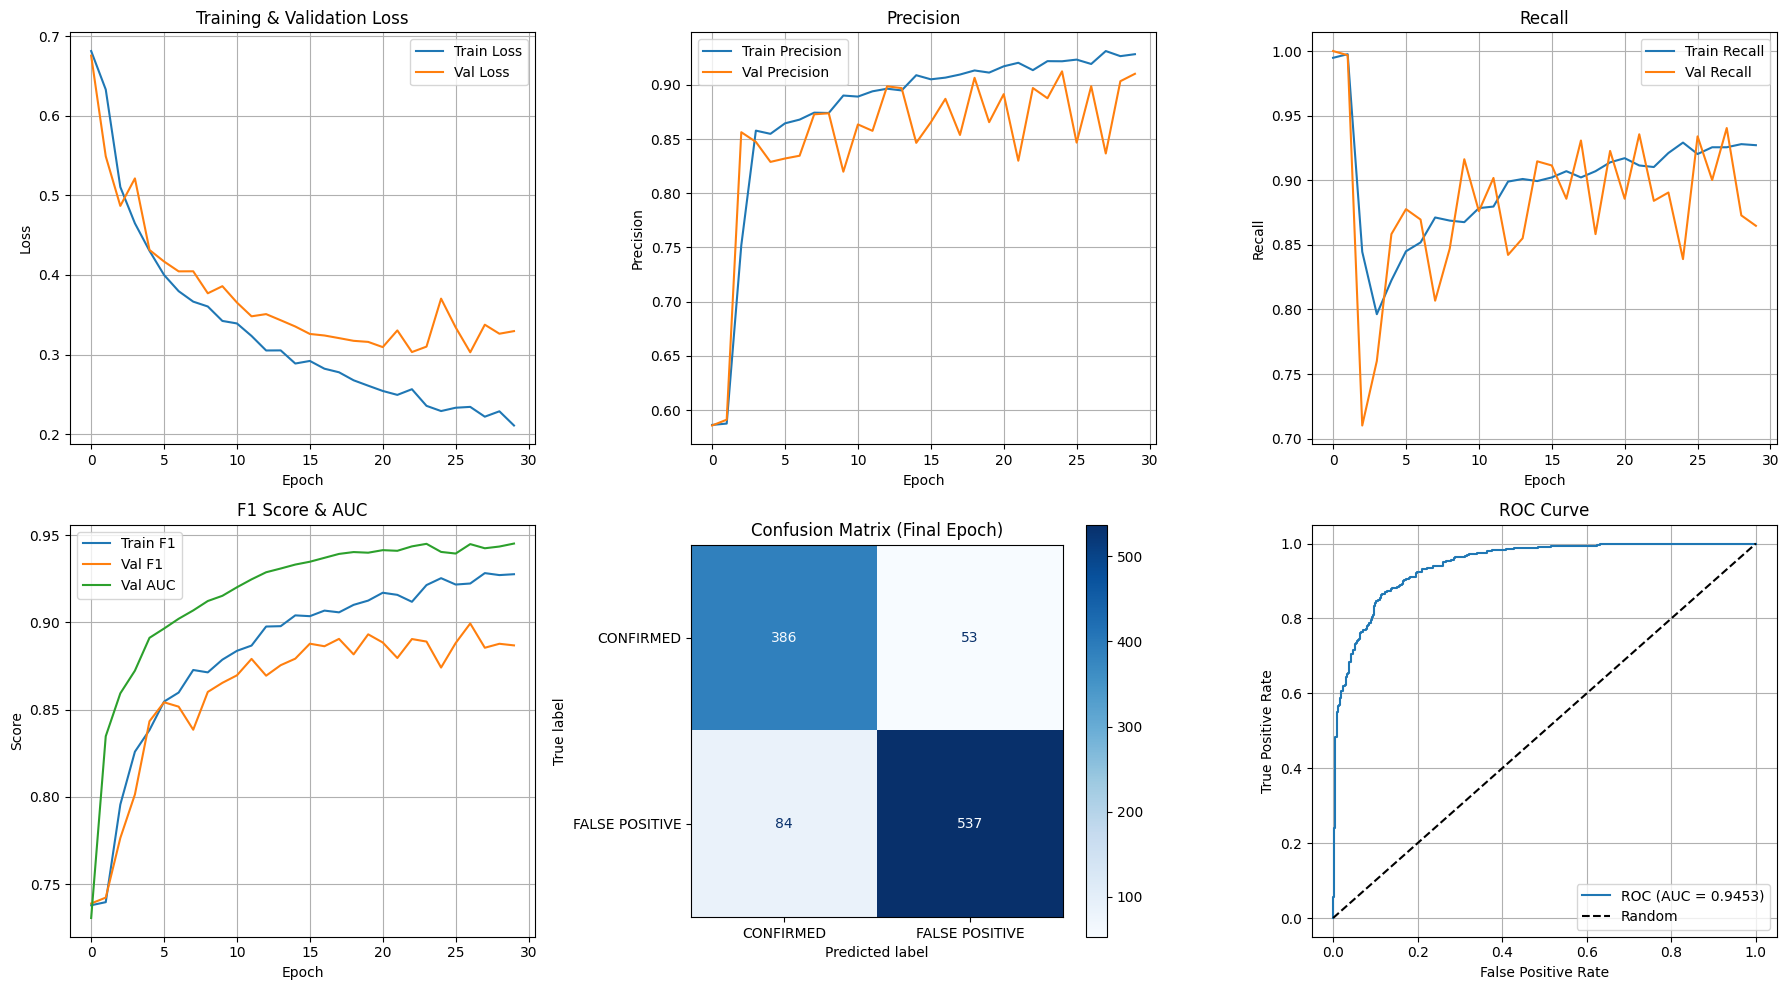


Best Validation AUC: 0.9453

Final Confusion Matrix:
[[386  53]
 [ 84 537]]

True Negatives: 386, False Positives: 53
False Negatives: 84, True Positives: 537

Training complete!


In [12]:
# ============================================================
# PLOT RESULTS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(train_losses, label='Train Loss')
axes[0, 0].plot(val_losses, label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Precision
axes[0, 1].plot(train_precisions, label='Train Precision')
axes[0, 1].plot(val_precisions, label='Val Precision')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Recall
axes[0, 2].plot(train_recalls, label='Train Recall')
axes[0, 2].plot(val_recalls, label='Val Recall')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Recall')
axes[0, 2].set_title('Recall')
axes[0, 2].legend()
axes[0, 2].grid(True)

# F1 & AUC
axes[1, 0].plot(train_f1s, label='Train F1')
axes[1, 0].plot(val_f1s, label='Val F1')
axes[1, 0].plot(val_aucs, label='Val AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('F1 Score & AUC')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(ax=axes[1, 1], cmap='Blues', values_format='d')
axes[1, 1].set_title('Confusion Matrix (Final Epoch)')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_probs)
axes[1, 2].plot(fpr, tpr, label=f'ROC (AUC = {auc:.4f})')
axes[1, 2].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 2].set_xlabel('False Positive Rate')
axes[1, 2].set_ylabel('True Positive Rate')
axes[1, 2].set_title('ROC Curve')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300)
plt.show()

print(f"\nBest Validation AUC: {best_auc:.4f}")
print(f"\nFinal Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
print("\nTraining complete!")

Agumentation Functions to prevent overfitting


Evaluation

Saving History to a csv file

In [ ]:
import pandas as pd

history = pd.DataFrame({
    "train_loss": train_losses,
    "val_loss": val_losses
})

history.to_csv("training_history.csv", index=False)


NameError: name 'val_accuracies' is not defined

Plotting the training and validation history